### Look at natural variation across topsoils

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO = 'K00370'
annotation = pd.read_csv(f'../data/dmndv0_s_{KO}_rep_q_topsoil_e_1e-5_pid_50.tsv', sep = '\t', header = None).values
sequences = pd
print(annotation.shape)

for i in range(10):
    print(annotation[i])
    


(175185, 12)
['FS101__C6797_L=452;_1' 'nfs:OIE67_54775' 56.0 50 16 1 4 47 291 340
 1.3e-08 53.5]
['FS101__C6797_L=452;_1' 'rub:GBA63_10615' 55.3 47 15 1 7 47 295 341
 1.4e-07 50.1]
['FS101__C6797_L=452;_1' 'gew:MF406_16270' 51.1 47 17 1 7 47 322 368
 1.8e-07 49.7]
['FS101__C6797_L=452;_1' 'asd:AS9A_2092' 53.2 47 16 1 7 47 308 354 2.4e-07
 49.3]
['FS101__C6797_L=452;_1' 'arev:RVR_4929' 50.0 50 19 1 4 47 332 381 4.1e-07
 48.5]
['FS101__C6797_L=452;_1' 'rub:GBA63_19395' 53.2 47 16 1 7 47 295 341
 4.1e-07 48.5]
['FS101__C6797_L=452;_1' 'sia:M1425_0828' 51.1 47 17 1 7 47 273 319
 4.1e-07 48.5]
['FS101__C6797_L=452;_1' 'sspo:DDQ41_29520' 51.0 49 18 1 5 47 304 352
 5.3e-07 48.1]
['FS101__C6797_L=452;_1' 'cef:CE1296' 51.1 47 17 1 7 47 301 347 7e-07 47.8]
['FS101__C6797_L=452;_1' 'rsua:LQF12_10045' 51.1 47 17 1 7 47 313 359
 9.1e-07 47.4]


In [ ]:
import gzip

# Read annotations and get unique sequence IDs
annotations = pd.read_csv('../data/topsoil/dmndv0_s_K00370_rep_q_topsoil_e_1e-5_pid_50.tsv', 
                         sep='\t', header=None)
unique_annotations = annotations.drop_duplicates(subset=0)  # Keep first occurrence per sequence ID
unique_ids = set(unique_annotations[0])

# Write unique annotations to file
unique_annotations.to_csv('../data/topsoil/K00370_unique_annotations.tsv', sep='\t', header=False, index=False)

# Filter FASTA sequences
with gzip.open('../data/raw_data/topsoil/compl.incompl.95.prot.faa.gz', 'rt') as f_in, \
     open('../data/topsoil/K00370_annotated_sequences.faa', 'w') as f_out:
    
    print_sequence = False
    current_id = ""
    
    for line in f_in:
        if line.startswith('>'):
            # Extract sequence ID (remove '>' and any additional info)
            current_id = line[1:].split()[0]
            print_sequence = current_id in unique_ids
        
        if print_sequence:
            f_out.write(line)

In [6]:

def filter_fasta_by_length(input_fasta, output_fasta, min_length=1000):
    """
    Filter FASTA file by sequence length
    """
    sequences_kept = 0
    total_sequences = 0
    
    with open(input_fasta, 'r') as f_in, open(output_fasta, 'w') as f_out:
        current_header = ""
        current_sequence = ""
        
        for line in f_in:
            if line.startswith('>'):
                # Process the previous sequence before starting new one
                if current_header and len(current_sequence) >= min_length:
                    f_out.write(current_header + current_sequence)
                    sequences_kept += 1
                
                # Start new sequence
                current_header = line
                current_sequence = ""
                total_sequences += 1
            else:
                current_sequence += line
        
        # Don't forget the last sequence
        if current_header and len(current_sequence) >= min_length:
            f_out.write(current_header + current_sequence)
            sequences_kept += 1
    
    print(f"Total sequences: {total_sequences}")
    print(f"Sequences kept (length >= {min_length}): {sequences_kept}")
    print(f"Filtered FASTA saved to: {output_fasta}")


filter_fasta_by_length('../data/topsoil/K00370_annotated_sequences.faa', '../data/topsoil/K00370_sequences_min1000aa.faa', 1000)

Total sequences: 12700
Sequences kept (length >= 1000): 120
Filtered FASTA saved to: ../data/topsoil/K00370_sequences_min1000aa.faa


In [8]:
from Bio import SeqIO
from Bio import pairwise2


# Load sequences
sequences = {}
for record in SeqIO.parse("../data/topsoil/K00370_sequences_min1000aa.faa", "fasta"):
    sequences[record.id] = str(record.seq)

seq_ids = list(sequences.keys())
n_seqs = len(seq_ids)

# Create alignment matrix
alignment_matrix = np.zeros((n_seqs, n_seqs))

print(f"Creating {n_seqs}x{n_seqs} alignment matrix...")

for i in range(n_seqs):
    for j in range(i, n_seqs):  # Only compute upper triangle + diagonal
        if i == j:
            # Self-alignment: score = sequence length
            alignment_matrix[i, j] = len(sequences[seq_ids[i]])
        else:
            # Pairwise alignment
            alignments = pairwise2.align.globalxx(sequences[seq_ids[i]], sequences[seq_ids[j]])
            alignment_matrix[i, j] = alignments[0][2]  # Get the score
            alignment_matrix[j, i] = alignment_matrix[i, j]  # Make symmetric

# Save as CSV with sequence IDs as row/column headers
matrix_df = pd.DataFrame(alignment_matrix, index=seq_ids, columns=seq_ids)
matrix_df.to_csv("../data/topsoil/alignment_matrix.tsv")

print(f"Alignment matrix saved to 'alignment_matrix.tsv'")
print(f"Matrix shape: {alignment_matrix.shape}")

Creating 120x120 alignment matrix...
Alignment matrix saved to 'alignment_matrix.tsv'
Matrix shape: (120, 120)


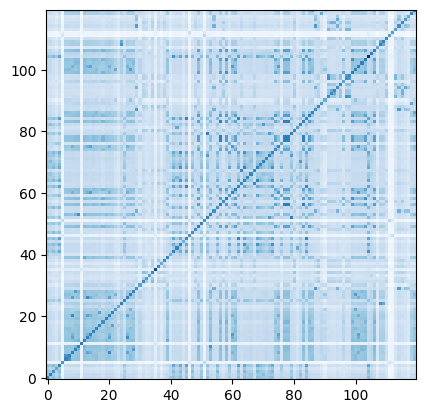

In [11]:
plt.imshow(alignment_matrix, cmap = 'Blues', origin = 'lower')
np.savetxt('../data/topsoil/alignment_matrix_min1000.tsv', alignment_matrix, delimiter='\t', fmt='%0.0f')